#  Supervised learning

**Supervised Learning is when we teach the computer with examples where the answers are already known.**

Input (X): The features (things we use to predict).

Output (y): The labels (the correct answer we want to predict).

The computer looks at many examples (X → y) and learns a mapping function:

𝑦=𝑓(𝑋)

Then, it can guess y for new X that it has never seen.

# What is our problem?

We want to answer this question:
**“If we know a patient’s age, BMI, blood pressure, and blood test results,
can we predict how much their diabetes will progress in 1 year?” as we have report data for 1 year**

# What is our goal?

Our goal is to build a machine learning model that:

Takes the 10 input features (X).

Predicts the progression score (y).

Does this accurately for new, unseen patients.

# Phase 3 selecting Libraries 

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes,load_iris

#  Phase 4: load data set and select the target variable

Features
Age, sex, BMI, BP, serum levels #The serum (s1–s6) are biological measurements related to blood tests


In [28]:

diabetes = load_diabetes()

# Convert to pandas DataFrame for easier handling
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names) #here data is a function which is 
print(df.head())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


# AFTER LOADING THE DATA

**Data Preprocessing Approaches (before modeling)**

When we get data, we usually need to prepare it so that ML models can understand and learn effectively.

Here are the main steps & approaches (with WHY they’re done):

**1. Data Cleaning** 🧹

What: Handle missing, wrong, or duplicate values.

Why: ML models can’t learn well if data is incomplete or messy.

How:

Remove rows/columns with too many missing values.

Replace missing numbers with mean/median.

Replace missing categories with mode or "Unknown".

Remove duplicates.

👉 Example: If BMI is missing for some patients, we can fill it with the average BMI.

**2. Feature Encoding 🔤 → (For Categorical Data)**

What: Convert text labels (like Male/Female, City names) into numbers.

Why: ML algorithms only understand numbers.

How:

Label Encoding: Convert categories into integers (Male=0, Female=1).

One-Hot Encoding: Create dummy columns (Gender_Male=1, Gender_Female=0).

👉 Example: "Yes/No" → [1/0].

**3. Feature Scaling 📏**

This is what you asked about (like standardization). It makes features comparable.

Main Approaches:

Standardization (Z-score scaling)


Mean = 0, Std Dev = 1.

Works well for algorithms like Linear Regression, Logistic Regression, SVM, KNN.

Example: Age 50 → becomes a value around 0.2 (after scaling).

Min-Max Scaling (Normalization)

Values are rescaled between 0 and 1.

Useful when features must be bounded (like Neural Networks).

Example: Age (20–80) → converted to 0.0–1.0 range.

Robust Scaling

Uses median and IQR (Interquartile Range).

Less sensitive to outliers.

Example: Salary data (where 1 billionaire would ruin min-max scaling).

👉 Why scaling is important?

Without scaling, algorithms like KNN or Gradient Descent may behave poorly because large values dominate smaller ones.

**4. Feature Selection / Dimensionality Reduction 🧠**

What: Reduce the number of features if too many exist.

Why: Too many features = complexity, overfitting.

How:

Remove irrelevant features.

Use PCA (Principal Component Analysis).

👉 Example: If we have 100 medical tests but only 5 really affect diabetes, we keep those 5.

**5. Train-Test Split 🏋️**

What: Split dataset into training set and test set (e.g., 80% train, 20% test).

Why: To check if our model generalizes to new data.

**6. Balancing Data (only for Classification) ⚖️**

What: If classes are imbalanced (e.g., 95% “No Disease”, 5% “Disease”), models may ignore the minority class.

How:
Oversample minority class (SMOTE).

Undersample majority class.

# As we already have standardized data so we can proceed with our problem

In [31]:
# Add the target (output) column
df['target'] = diabetes.target
# The dataset you loaded already included the target column.
# Your step of adding it to the DataFrame (df['target'] = diabetes.target) just makes it easier to work with, but the data was there originally.

In [32]:
df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


# Phase 5: Visualizing Data (Why visualization first?) 
Before training, we must see relationships in data. Visualization helps us:

Detect patterns.

Spot irrelevant features.

Get intuition about the problem.

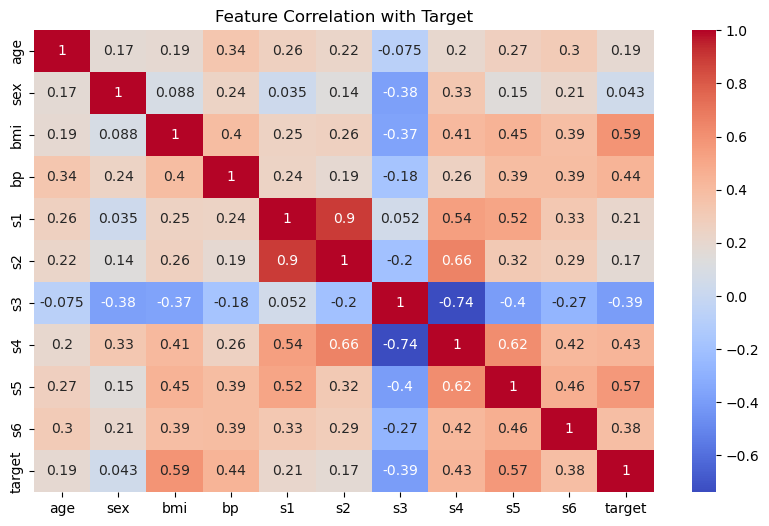

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Target")
plt.show

'''
Visualizations help you understand which variables might be important (e.g., bmi, bp, s5).

You can decide whether to remove or transform variables before training.

After splitting, you never touch the test data again until evaluation.
'''

 **So till here i have already cleaned , standerdized and feature selection now we move to the next step** 
# Phase 6 train test and split

**Train-Test Split (Why important?)**

If we train and test on the same data, the model can “memorize” instead of learning (this is called overfitting).

To prevent this, we split the data:

Training set (80%) → To teach the model.

Test set (20%) → To check performance on new data.**

In [33]:
from sklearn.model_selection import train_test_split

x=df.drop('target',axis=1) #input data 
#if in case i want to drop multiple columns ----> df.drop(columns=['column_1', 'column_2', 'column_3'], inplace=True)
y=df['target'] #labeled data

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) #random_states= 42 means you are telling your machine to start shuffel from no 42

print(x_train.shape)
print(x_test.shape)



(353, 10)
(89, 10)


# scaling of data
**You should scale your data after the train-test split.**

This is a critical step to prevent a problem called data leakage, which can lead to overly optimistic performance metrics and a model that performs poorly on truly new, unseen data

| Model Type                       | Scaling Needed? | Recommended Scaler             |
| -------------------------------- | --------------- | ------------------------------ |
| Linear Regression, Ridge, Lasso  | ✅ Yes           | StandardScaler                 |
| SVM / SVR                        | ✅ Yes           | StandardScaler or MinMaxScaler |
| KNN                              | ✅ Yes           | StandardScaler or MinMaxScaler |
| Neural Networks                  | ✅ Yes           | MinMaxScaler (usually 0–1)     |
| Tree-based (RF, GB, DT, XGBoost) | 🚫 No           | None needed                    |
| Naive Bayes                      | 🚫 Usually no   | None                           |
| Logistic Regression              | ✅ Yes           | StandardScaler                 |




**When You Do Not Need Scaling**

Some models don’t care about feature scales at all — mainly tree-based algorithms.

✅ No scaling needed for:

DecisionTreeRegressor / Classifier

RandomForest

GradientBoosting

XGBoost / LightGBM / CatBoost

In [42]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()

In [43]:
x_train_scale= scale.fit_transform(x_train)
x_test_scale=scale.fit_transform(x_test)

**question:** why we are not scaling our Target data?.

Task Type	Target (Y)	Why We Don't Scale
Classification	Labels (e.g., 0, 1, 'Dog', 'Cat')	The answer is a specific category. Scaling it turns 0 and 1 into weird numbers that make no sense, breaking the whole task.

Regression	Continuous Value (e.g., Price, Temperature)	We need the final answer in the original, real-world units (e.g., "$500,000"). If you scale it, the model predicts a scaled number (e.g., "0.5"), and you have to do an extra step to convert it back to a price. It's simpler to just train the model to predict the price directly.

# Model selection

picking which kind of algorithm can best learn the relationship between X and y.

There are different families of models depending on the data pattern.

**(a) Baseline Model — Linear Regression**
📊 Summary Table:
Type	
    
Simple Linear Regression	1	BMI → disease score	y = β₀ + β₁x₁	LinearRegression()
Multiple Linear Regression	2 or more	Age, BMI, BP → disease score	y = β₀ + β₁x₁ + β₂x₂ + ...	LinearRegression()

In [45]:
#training the model on train data
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_scale, y_train)   # Train on training data


LinearRegression()

# Make Predictions

In [47]:
y_pred = model.predict(x_test_scale)
y_pred

#y_pred contains the predicted disease progression scores for your test patients.

array([149.75685653, 191.23894878, 144.99765835, 308.2392461 ,
       135.55185658, 101.11224602, 269.52744222, 194.08720525,
       102.71279275, 118.74805116, 104.00999166, 182.3985081 ,
        63.75470836, 222.58497547, 112.88024423, 142.88173554,
       232.5232517 , 265.55754803, 212.47025262, 233.06931101,
       219.77085051,  97.16940484,  79.87840784, 203.12202014,
       165.17609256, 172.95901167, 201.65514889, 196.37081952,
        57.15895691, 120.31482889, 183.09312592,  96.80797149,
       142.66542464, 199.39529609, 183.05559088, 203.0955264 ,
       136.64072601, 131.6510423 , 161.32453782,  67.29605716,
        82.3243273 , 120.3548651 , 180.07818504, 167.78833731,
       185.60340222,  69.74095708,  80.71614044, 126.40349108,
        61.95206421, 179.21497496, 161.70371134,  72.54003606,
       112.89003338, 120.07078536, 191.22782172, 164.38704828,
       104.59273454, 224.0885385 , 130.33918852,  86.18585062,
       199.55111706, 218.74507338, 151.04307119, 119.18

# Now Evaluate the Model

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R² Score:", r2)


MSE: 2972.8515346999225
MAE: 43.24547555275302
R² Score: 0.43888894168947246


On average, your model is off by ≈ 43 units.

Squared errors average to ≈ 2859, showing some large misses.

R² = 0.46 → your model explains 46% of the variation in diabetes progression — not bad for a simple linear regression!

**the evaluation explanation**

Smaller MSE = better model.  It measures how far off the model’s predictions are from the actual values

maller MAE = smaller average error.It tells you the average size of errors (in the same units as your target).

R² tells you how well your model explains the variation in the target.

It’s a value between 0 and 1 (sometimes negative if the model is really bad).

R² Value	Meaning
1.0	Perfect prediction
0.9	90% of variance explained
0.5	Model explains half the variance
0.0	Model explains nothing
Negative	Model is worse than just predicting the mean

It means your model understands the reason behind the differences in target values.
High-scoring students studied more hours → model captures that.
Low-scoring students studied less → model captures that.
So, “explaining variation” really means your model follows the real-world pattern that causes those differences.

# to see actual target value (y_test)vs predicted (y_pred)side by side

**that is why we did model evaluation)**


In [51]:
comparision=pd.DataFrame({'Actual_target_value':y_test,'predicted_taget_value_by_the model':y_pred})
print(comparision.head(10))


     Actual_target_value  predicted_taget_value_by_the model
287                219.0                          149.756857
211                 70.0                          191.238949
72                 202.0                          144.997658
321                230.0                          308.239246
73                 111.0                          135.551857
418                 84.0                          101.112246
367                242.0                          269.527442
354                272.0                          194.087205
281                 94.0                          102.712793
148                 96.0                          118.748051


In [54]:
# WE CAN ALSO CHECK THE ACCURACY SCORE --->its a regression not classification. so accuracy score calculated in classification model
'''from sklearn import metrics 
accu=metrics.accuracy_score(y_test,y_pred)
accu'''

'from sklearn import metrics \naccu=metrics.accuracy_score(y_test,y_pred)\naccu'

as we see  our r2 is only 43%  so we need to do something to improve our model
for that we need to go through Regularization aproach.

so which one should we go?
it depends on your goal and your data 👇

Case	Choose
Many correlated features (like BMI, BP, age are related)	Ridge
Want to find which features are most important	Lasso
Want both (stability + feature selection)	ElasticNet (combines both)


In [62]:
# Ridge regression l2
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error ,mean_absolute_error,r2_score

ridge=Ridge(alpha=1.0)
ridge.fit(x_train_scale,y_train)

y_pred_ridge= ridge.predict(x_test_scale)

MSE= mean_squared_error(y_pred_ridge,y_test)

MAE=mean_absolute_error(y_pred_ridge,y_test)

R2= r2_score(y_pred_ridge,y_test)


print(MSE,MAE,R2)


2956.2695823331956 43.240099412673175 0.02578646784089067


In [64]:
# Lasso Regression l1
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error ,mean_absolute_error,r2_score
lasso= Lasso(alpha=0.1)
lasso.fit(x_train_scale,y_train)
y_pred_lasso=lasso.predict(x_test_scale)

MSE= mean_squared_error(y_pred_lasso,y_test)

MAE=mean_absolute_error(y_pred_lasso,y_test)

R2= r2_score(y_pred_lasso,y_test)


print(MSE,MAE,R2)



2944.6071740307484 43.21338267343737 0.021301125263886056


In [ ]:
Let’s compare all your models side by side:

Model	             MSE	MAE	    R²
Linear Regression	2972.85	43.25	0.4389
Ridge Regression	2956.27	43.24	0.0258
Lasso Regression	2944.60	43.21	0.0213

🧩 Step 1: Look at R² first

Your Linear Regression has R² = 0.4389, which means:

“My model explains about 43.9% of the variation in the diabetes target values.”

That’s decent — not perfect, but solid for this dataset.
Now, your Ridge and Lasso R² dropped to near 0.02, which means:

“They explain almost nothing — worse than the plain Linear model.”

🧠 Step 2: Why did this happen?

Let’s understand what’s going on conceptually:

**Model**    ||  	**What It Does**	 ||        **When It Helps**	   ||        **What Happened Here**

Linear 	Fits the data freely	Works when there’s low overfitting	      ✅ Performed well

Ridge	Shrinks coefficients (L2)	Helps when model is overfitting	      ❌ It was underfitting, not overfitting

Lasso	Shrinks some coefficients to 0 (L1)	Helps with too many features  ❌ We don’t have too many features (only 10)

**Conclusion**

Your base Linear Regression is currently the best-performing model.
This tells us two key things:

1️⃣ No signs of overfitting — test R² (0.44) is reasonable.

2️⃣ Regularization not needed yet, because it actually hurt the model.